In [2]:
import os
import cv2
import random
import matplotlib.pyplot as plt  
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

# 构建数据集

In [3]:
# 数据增强和输入大小变换
train_transform = transforms.Compose([
    transforms.Resize([224,224]),                        # 调整到224x224
    transforms.ToTensor(),                               # 转换为张量
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.229, 0.224, 0.225])    # 标准化
])
test_transform = transforms.Compose([
    transforms.Resize([224,224]),             # 调整到224x224
    transforms.ToTensor(),                    # 转换为张量
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.229, 0.224, 0.225])    # 标准化
])
# 创建dataset类
class LFWPairDataset(Dataset):
    def __init__(self, root_dir, pairs_file, transform=None):
        """
        Args:
            root_dir (str): LFW 数据集的根目录
            pairs_file (str): pairsDev____.txt 文件路径
            transform (callable, optional): 图像变换函数
        """
        self.root_dir = root_dir
        self.transform = transform
        self.pairs = []

        # 读取 pairsDev____.txt 文件
        with open(pairs_file, 'r') as f:
            lines = f.readlines()[1:]  # 跳过第一行
            for line in lines:
                items = line.strip().split()
                if len(items) == 3:  # 正样本对
                    name, img1_idx, img2_idx = items
                    img1_path = os.path.join(root_dir, name, f"{name}_{int(img1_idx):04d}.jpg")
                    img2_path = os.path.join(root_dir, name, f"{name}_{int(img2_idx):04d}.jpg")
                    self.pairs.append((img1_path, img2_path, 1))  # 标签为 1
                elif len(items) == 4:  # 负样本对
                    name1, img1_idx, name2, img2_idx = items
                    img1_path = os.path.join(root_dir, name1, f"{name1}_{int(img1_idx):04d}.jpg")
                    img2_path = os.path.join(root_dir, name2, f"{name2}_{int(img2_idx):04d}.jpg")
                    self.pairs.append((img1_path, img2_path, 0))  # 标签为 0
        print("样本数量：",len(self.pairs))
    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        # 加载图像
        img1 = Image.open(img1_path)
        img2 = Image.open(img2_path)
        img1.show()
        # 应用变换
        if self.transform:
            img1 = self.transform(img1)*255
            img2 = self.transform(img2)*255

        # 返回图像对及标签
        return img1, img2, torch.tensor(label, dtype=torch.float32)


# 初始化数据集
train_dataset = LFWPairDataset(root_dir='../data/lfw_funneled/',pairs_file='../data/pairsDevTrain.txt',transform=train_transform)
test_dataset = LFWPairDataset(root_dir='../data/lfw_funneled/',pairs_file='../data/pairsDevTest.txt',transform=test_transform)

# 创建dataloader
batch_size = 256
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=14)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=True,num_workers=14)


样本数量： 2200
样本数量： 1000


In [4]:
print(len(train_loader))

9


# 搭建以resnet18网络模型为基础的孪生神经网络，并构建对比损失函数

In [5]:
# 孪生神经网络
class SiameseNet(nn.Module):
    def __init__(self):
        super(SiameseNet, self).__init__()
        # 加载预训练的 ResNet
        self.feature_extractor = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor.fc = nn.Identity()  # 去掉最后的全连接层
        self.fc = nn.Linear(512,128)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)  # Flatten
        x = self.fc(x)
        return F.normalize(x)  # L2 归一化

# 实例化模型
model = SiameseNet()
print(model)


SiameseNet(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

# 定义训练函数与测试函数

In [6]:
import time
from sklearn.metrics import accuracy_score
# 训练函数
def train(train_loader,model, criterion, optimizer,batch_size,device):
    model.train()

    epoch_loss = 0
    correct_sum = 0
    threshold = 0.6  # 距离阈值设置

    y_true, y_pred = [], []
    for X1,X2,y in tqdm(train_loader):
        X1,X2,y = X1.to(device),X2.to(device),y.to(device)
        
        optimizer.zero_grad()

        # 输出两张图像的特征向量
        output1 = model(X1)
        output2 = model(X2)

        cosine_similarity = F.cosine_similarity(output1,output2)
        # 计算损失
        loss = criterion(cosine_similarity, y)
        epoch_loss += loss.item()
        # 计算准确率(当余弦相似度超过阈值即为判断为正样本) 
        predictions = ((cosine_similarity+1)/2 > threshold).cpu().float() 
        y_true.extend(y.cpu().numpy())
        y_pred.extend((predictions))

        loss.backward()
        optimizer.step()

    accuracy = accuracy_score(y_true, y_pred)
    return epoch_loss / len(train_loader), accuracy

# 测试函数
def test(test_loader,model,criterion,batch_size,device):
    model.eval()

    threshold = 0.6 # 距离阈值设置
    TP = 0 
    FP = 0
    FN = 0
    TN = 0
    epoch_loss = 0
    distance_list = []
    y_true, y_pred = [], []

    with torch.no_grad():
        for X1,X2,y in tqdm(test_loader):
            X1,X2,y = X1.to(device),X2.to(device),y.to(device)

            output1 = model(X1)
            output2 = model(X2)

            cosine_similarity = F.cosine_similarity(output1,output2)
            loss = criterion(cosine_similarity, y)
            
            epoch_loss += loss.item()
            
            #计算损失
            epoch_loss += loss.item()

            distance_list.extend(cosine_similarity.cpu().numpy())
            # 计算准确率
            predictions = ((cosine_similarity+1)/2 > threshold).cpu().float() 
            y_true.extend(y.cpu().numpy())
            y_pred.extend((predictions))
            
            # 计算混淆矩阵指标
            TP += ((predictions+y.cpu()) == 2).sum().item()   # 真阳性  
            FP += ((predictions-y.cpu()) == 1).sum().item()   # 假阳性
            FN += ((predictions-y.cpu()) == -1).sum().item()  # 假阴性
            TN += ((predictions+y.cpu()) == 0).sum().item()   # 真阴性

    accuracy = accuracy_score(y_true, y_pred)
    return epoch_loss/len(test_loader),accuracy,TP,FP,FN,TN,distance_list,y_true
 

# 模型训练

In [14]:
model = torch.load('face_validation.pth')

# 模型超参数
num_epochs = 10
learning_rate = 0.005


# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

# 训练循环
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)


# 指标记录
train_loss_history = []
train_accuracy_history = []
test_loss_history = []
test_accuracy_history = []


best_loss = float('inf')


# 边训练边测试，保存效果最好的模型，防止过拟合
for epoch in range(num_epochs): 
    start_time = time.time()
    train_loss,train_accuracy= train(train_loader,model,criterion,optimizer,batch_size,device)
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)

    with torch.no_grad():
        test_loss,accuracy,TP,FP,FN,TN,_,_ = test(test_loader,model,criterion,batch_size,device)
        test_loss_history.append(test_loss)
        test_accuracy = (TP+TN)/(TP+FP+FN+TN)
        test_accuracy_history.append(test_accuracy)
    if test_loss<best_loss: 
        torch.save(model,"face_validation.pth")
        best_loss = test_loss
    
    print(f" Epoch:{epoch+1}/{num_epochs}, train loss: {train_loss:>8f},train accuracy: {train_accuracy*100:>0.1f}%, test_loss: {test_loss:>8f},test_accuracy:{test_accuracy*100:0.1f}%, time: {time.time()-start_time:.2f} s")



cuda


100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


 Epoch:1/50, train loss: 0.655091,train accuracy: 63.3%, test_loss: 1.537006,test_accuracy:51.2%, time: 10.33 s


100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


 Epoch:2/50, train loss: 0.625353,train accuracy: 66.6%, test_loss: 1.328307,test_accuracy:62.2%, time: 10.52 s


...

 Epoch:48/50, train loss: 0.402819,train accuracy: 94.0%, test_loss: 1.406204,test_accuracy:57.4%, time: 10.60 s


100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


 Epoch:49/50, train loss: 0.398842,train accuracy: 94.2%, test_loss: 1.400591,test_accuracy:57.6%, time: 10.61 s


100%|██████████| 4/4 [00:04<00:00,  1.09s/it]


 Epoch:50/50, train loss: 0.396408,train accuracy: 94.6%, test_loss: 1.394120,test_accuracy:57.8%, time: 10.57 s


In [8]:
# 保存结果
def save_list_to_text(filename, data):
    with open(filename, 'w') as file:
        for item in data:
            file.write("%s\n" % item) 
# 读取结果
def read_list_from_text(filename):
    with open(filename, 'r') as file:
        data = np.float32(file.readlines())
    return data     
# 保存指标记录
save_list_to_text('txt/train_loss_history.txt',train_loss_history)
save_list_to_text('txt/train_accuracy_history.txt',train_accuracy_history)
save_list_to_text('txt/test_loss_history.txt',test_loss_history)
save_list_to_text('txt/test_accuracy_history.txt',test_accuracy_history)

# 训练过程变化

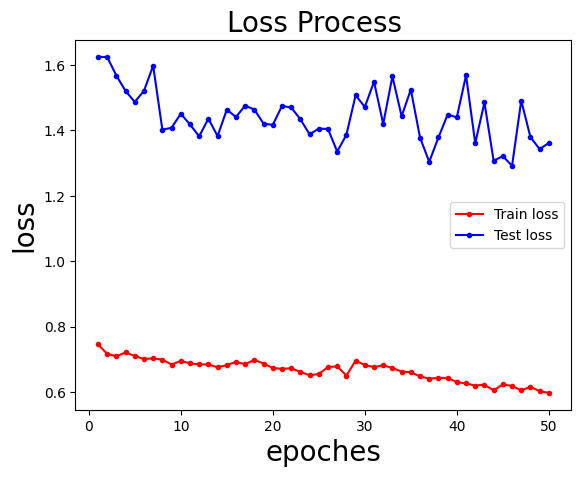

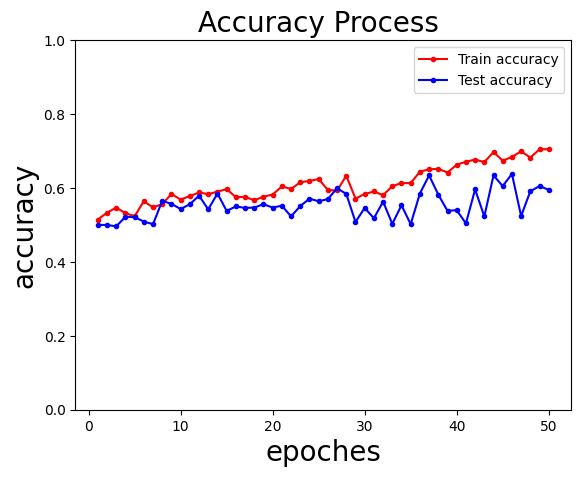

In [9]:
#读取指标记录
train_loss_history = read_list_from_text('txt/train_loss_history.txt')
train_accuracy_history = read_list_from_text('txt/train_accuracy_history.txt')
test_loss_history = read_list_from_text('txt/test_loss_history.txt')
test_accuracy_history = read_list_from_text('txt/test_accuracy_history.txt')


# 绘制训练和测试损失
x  = range(1, num_epochs+1)
plt.title('Loss Process  ', fontsize=20)
plt.plot(x, train_loss_history, '.-', color='red', label='Train loss')
plt.plot(x, test_loss_history, '.-', color='blue', label='Test loss')
plt.xlabel('epoches', fontsize=20)
plt.ylabel('loss', fontsize=20)
plt.legend()
plt.savefig('png/loss.png') #保存图像
plt.show()


# 绘制训练和测试准确率
plt.title('Accuracy Process ', fontsize=20)
plt.plot(x, train_accuracy_history, '.-',color = 'red', label='Train accuracy')
plt.plot(x, test_accuracy_history, '.-',color = 'blue', label='Test accuracy')
plt.xlabel('epoches', fontsize=20)
plt.ylabel('accuracy', fontsize=20)
plt.ylim(0, 1)
plt.legend()
plt.savefig('png/accuracy.png') #保存图像
plt.show()


# 模型评估

In [10]:
# 加载模型
model = torch.load("face_validation.pth")
model.eval()
batch_size = 80
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    test_loss,_,TP,FP,FN,TN,distance1_list,y_list= test(test_loader,model,criterion,batch_size,device)
    #计算指标
    accuracy = (TP+TN)/(TP + FP + FN + TN)
    precision = TP/(TP + FP)
    recall = TP/(TP + FN)
    F1_score = 2*precision*recall/(precision + recall)
    
    print(f"Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1_score: {F1_score:.2f}")



100%|██████████| 4/4 [00:03<00:00,  1.01it/s]

Accuracy: 59.50%
Precision: 0.62
Recall: 0.72
F1_score: 0.67


### 绘制ROC曲线

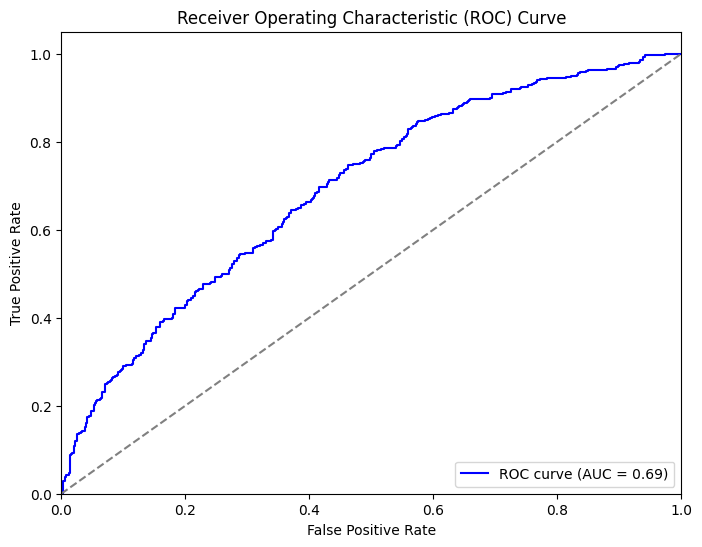

In [11]:
from sklearn.metrics import roc_curve, auc

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_list,distance1_list)  # all_distances 为每对样本的距离
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig('png/ROC.png') #保存图像
plt.show()



### 绘制PR曲线

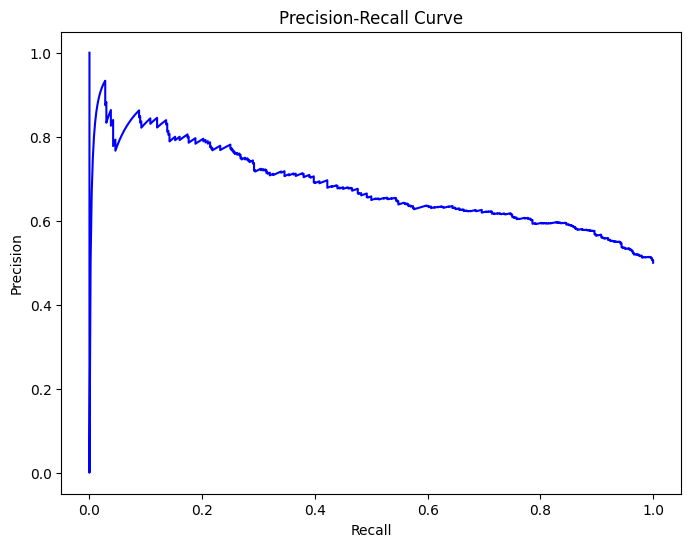

In [12]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_list, distance1_list)

# 绘制 PR 曲线
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.savefig('png/PR.png') #保存图像
plt.show()

### 绘制混淆矩阵

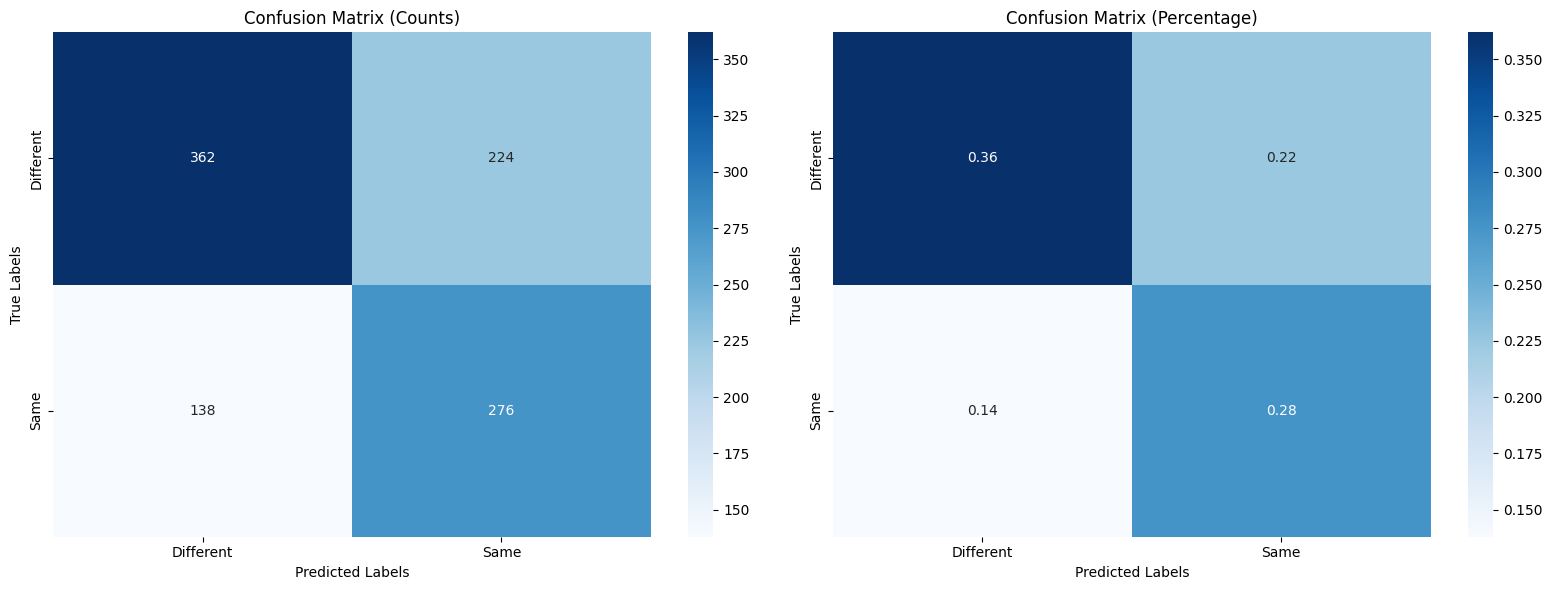

In [13]:
import seaborn as sns

c_matrix = np.array([[TP, FP], [FN, TN]])
c_matrix_percentage = c_matrix.astype(np.float32) / c_matrix.sum()  # 转换为百分比

# 设置图像大小
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 绘制普通混淆矩阵
sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Different', 'Same'], yticklabels=['Different', 'Same'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# 绘制带百分比的混淆矩阵
sns.heatmap(c_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Different', 'Same'], yticklabels=['Different', 'Same'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentage)')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

# 调整布局并显示图像
plt.tight_layout()
plt.savefig('png/confusion_matrix.png') #保存图像
plt.show()